# IA Aplicada à Lotofácil: Análise Estatística e Previsão com Machine Learning

Este notebook demonstra como aplicar técnicas de **Inteligência Artificial e análise estatística** ao histórico real de sorteios da **Lotofácil**.

Utilizamos conceitos de:
- **Análise de frequência** — quais números aparecem mais
- **Análise de atraso** — quantos sorteios um número ficou sem aparecer
- **Tendência recente** — comportamento nos últimos sorteios
- **Score composto** — modelo ponderado para gerar uma sugestão de aposta
- **Árvore de Decisão** — classificação supervisionada (quente × frio)

> **Aviso importante:** Este notebook é estritamente educacional. A Lotofácil é um sorteio **aleatório**. Nenhum método estatístico garante acerto. O objetivo é aprender técnicas de IA com dados reais.

In [26]:
# Instalar e importar bibliotecas necessárias
!pip install scikit-learn pandas matplotlib seaborn --quiet

# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print(" Bibliotecas importadas com sucesso!")

 Bibliotecas importadas com sucesso!



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Etapa 1 — Carregar os Dados Históricos

O arquivo CSV contém o histórico dos sorteios da Lotofácil com os **15 números sorteados** em cada concurso, ordenados de forma crescente.

In [27]:
# Carregar o arquivo CSV com o histórico de sorteios
# Faça upload do arquivo no Colab antes de rodar esta célula

df = pd.read_csv('loteria.csv', sep=';')  # Ajuste o separador se necessário

# Identificar colunas das bolas
ball_cols = [c for c in df.columns if 'bola' in c]

print(f"Total de sorteios carregados: {len(df)}")
print(f"Concursos de {df['Concurso'].min()} a {df['Concurso'].max()}")
print(f"Colunas de bolas: {ball_cols}")
print()
df.head()

Total de sorteios carregados: 293
Concursos de 3283 a 3575
Colunas de bolas: ['bola1', 'bola2', 'bola3', 'bola4', 'bola5', 'bola6', 'bola7', 'bola8', 'bola9', 'bola10', 'bola11', 'bola12', 'bola13', 'bola14', 'bola15']



,Concurso,Data,bola1,bola2,bola3,bola4,bola5,bola6,bola7,bola8,bola9,bola10,bola11,bola12,bola13,bola14,bola15
0,3575,30/12/2025,2,4,5,7,8,9,10,12,13,14,15,17,21,22,25
1,3574,29/12/2025,1,3,4,5,6,8,12,13,15,16,17,18,20,21,25
2,3573,27/12/2025,1,2,7,8,10,11,12,14,15,16,17,20,22,23,25
3,3572,26/12/2025,1,2,4,5,7,10,12,14,15,16,17,18,19,22,24
4,3571,24/12/2025,2,3,4,5,6,8,11,12,13,14,17,20,22,24,25


## Etapa 2 — Análise de Frequência

A **frequência** indica quantas vezes cada número foi sorteado ao longo de todos os concursos. Na Lotofácil, como são sorteados 15 de 25 números, a probabilidade teórica de cada número aparecer em um sorteio é de **60%**.

In [28]:
# Calcular a frequência de cada número (1 a 25)

all_numbers = []
for _, row in df.iterrows():
    for c in ball_cols:
        all_numbers.append(int(row[c]))

freq = Counter(all_numbers)
freq_df = pd.DataFrame({
    'numero': list(range(1, 26)),
    'frequencia': [freq[n] for n in range(1, 26)],
    'percentual': [round(freq[n] / len(df) * 100, 1) for n in range(1, 26)]
})

print("Frequência de cada número:")
print(freq_df.to_string(index=False))

Frequência de cada número:
 numero  frequencia  percentual
      1         189        64.5
      2         174        59.4
      3         175        59.7
      4         176        60.1
      5         167        57.0
      6         177        60.4
      7         179        61.1
      8         162        55.3
      9         166        56.7
     10         163        55.6
     11         190        64.8
     12         174        59.4
     13         184        62.8
     14         185        63.1
     15         188        64.2
     16         166        56.7
     17         178        60.8
     18         168        57.3
     19         176        60.1
     20         169        57.7
     21         174        59.4
     22         183        62.5
     23         164        56.0
     24         183        62.5
     25         185        63.1


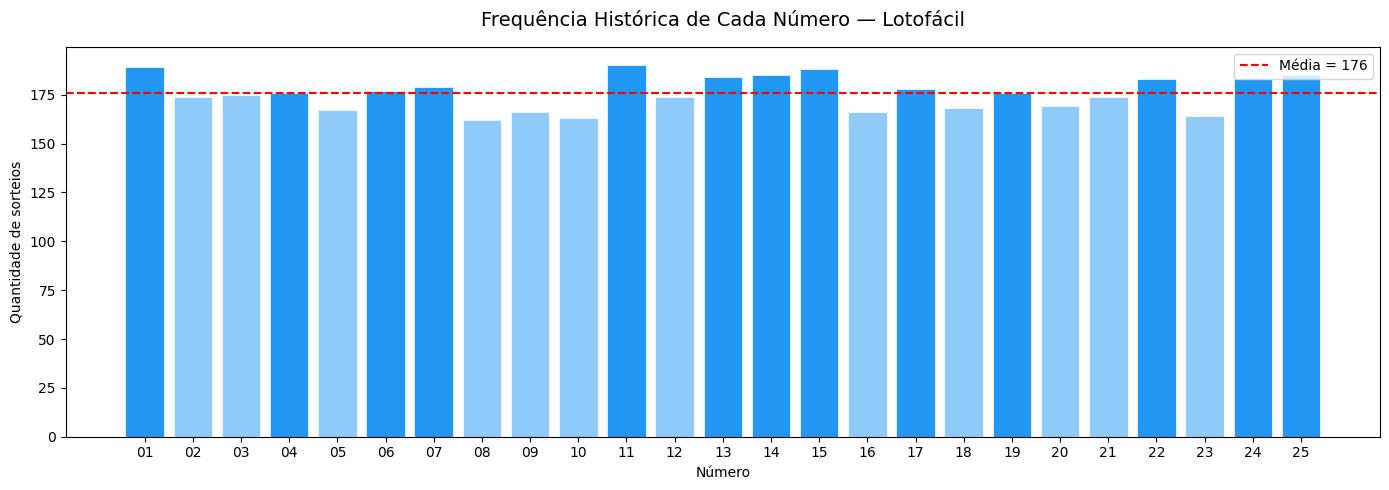


Número mais sorteado: 11 (190 vezes)
Número menos sorteado: 8 (162 vezes)


In [29]:
# Visualizar a frequência como gráfico de barras

plt.figure(figsize=(14, 5))
cores = ['#2196F3' if freq[n] >= freq_df['frequencia'].median() else '#90CAF9'
         for n in range(1, 26)]
bars = plt.bar([str(n).zfill(2) for n in range(1, 26)],
               [freq[n] for n in range(1, 26)],
               color=cores, edgecolor='white', linewidth=0.5)

# Linha de média
media = freq_df['frequencia'].mean()
plt.axhline(media, color='red', linestyle='--', linewidth=1.5, label=f'Média = {media:.0f}')

plt.title('Frequência Histórica de Cada Número — Lotofácil', fontsize=14, pad=15)
plt.xlabel('Número')
plt.ylabel('Quantidade de sorteios')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nNúmero mais sorteado: {freq_df.loc[freq_df['frequencia'].idxmax(), 'numero']} "
      f"({freq_df['frequencia'].max()} vezes)")
print(f"Número menos sorteado: {freq_df.loc[freq_df['frequencia'].idxmin(), 'numero']} "
      f"({freq_df['frequencia'].min()} vezes)")

## Etapa 3 — Análise de Atraso

O **atraso** indica quantos sorteios consecutivos um número ficou sem aparecer até o último concurso disponível. Números com maior atraso estão há mais tempo "devendo" aparecer.

In [30]:
# Calcular o atraso de cada número (sorteios desde a última aparição)
# O dataframe está em ordem decrescente: índice 0 = sorteio mais recente

delay = {}
for n in range(1, 26):
    for idx, row in df.iterrows():
        nums = set(int(row[c]) for c in ball_cols)
        if n in nums:
            delay[n] = idx  # quantos sorteios atrás apareceu
            break
    else:
        delay[n] = len(df)  # nunca apareceu (não deve ocorrer)

delay_df = pd.DataFrame({
    'numero': list(range(1, 26)),
    'atraso': [delay[n] for n in range(1, 26)]
})

print("Atraso de cada número (em sorteios):")
print(delay_df.to_string(index=False))
print(f"\nMaior atraso: número {delay_df.loc[delay_df['atraso'].idxmax(), 'numero']} "
      f"({delay_df['atraso'].max()} sorteios)")

Atraso de cada número (em sorteios):
 numero  atraso
      1       1
      2       0
      3       1
      4       0
      5       0
      6       1
      7       0
      8       0
      9       0
     10       0
     11       2
     12       0
     13       0
     14       0
     15       0
     16       1
     17       0
     18       1
     19       3
     20       1
     21       0
     22       0
     23       2
     24       3
     25       0

Maior atraso: número 19 (3 sorteios)


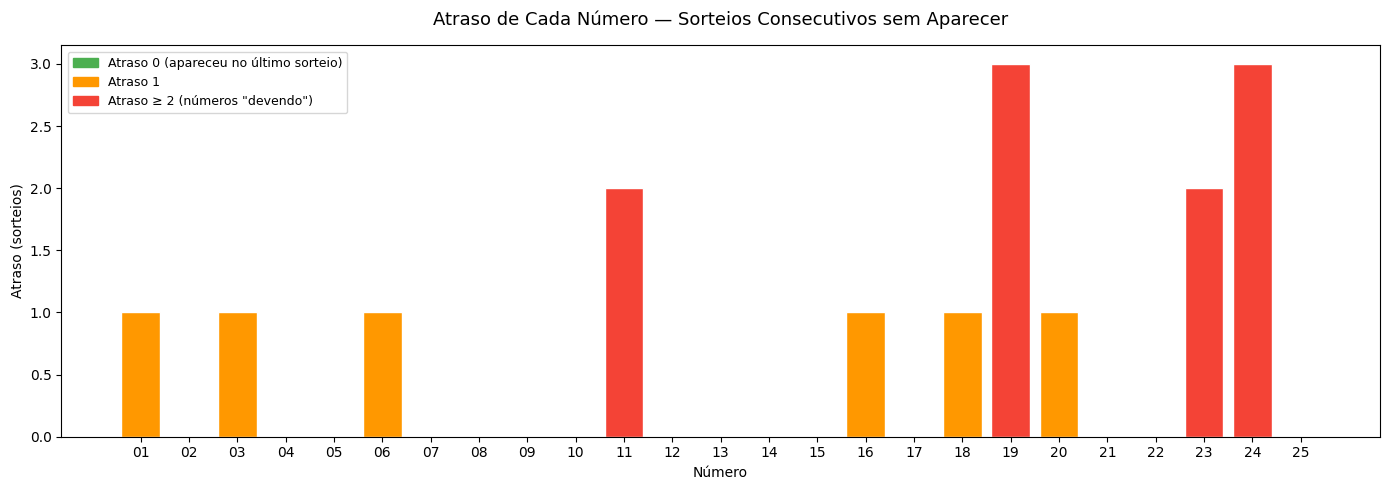

In [31]:
# Visualizar o atraso

plt.figure(figsize=(14, 5))
cores_atraso = ['#F44336' if delay[n] >= 2 else '#FF9800' if delay[n] == 1 else '#4CAF50'
                for n in range(1, 26)]
plt.bar([str(n).zfill(2) for n in range(1, 26)],
        [delay[n] for n in range(1, 26)],
        color=cores_atraso, edgecolor='white')

# Legenda manual
p1 = mpatches.Patch(color='#4CAF50', label='Atraso 0 (apareceu no último sorteio)')
p2 = mpatches.Patch(color='#FF9800', label='Atraso 1')
p3 = mpatches.Patch(color='#F44336', label='Atraso ≥ 2 (números "devendo")')
plt.legend(handles=[p1, p2, p3], fontsize=9)

plt.title('Atraso de Cada Número — Sorteios Consecutivos sem Aparecer', fontsize=13, pad=15)
plt.xlabel('Número')
plt.ylabel('Atraso (sorteios)')
plt.tight_layout()
plt.show()

## Etapa 4 — Tendência Recente (Últimos 30 Sorteios)

A tendência recente captura o comportamento **de curto prazo** dos números, filtrando os últimos 30 concursos da base.

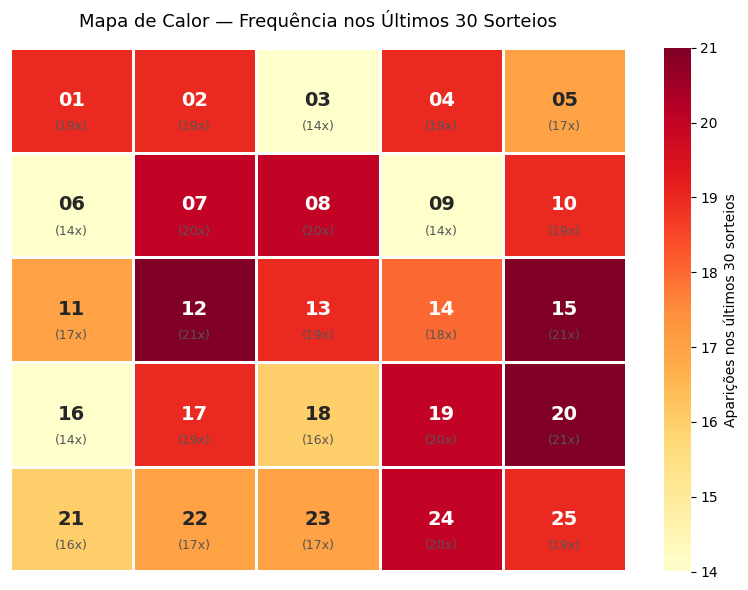

In [32]:
# Calcular frequência nos últimos 30 sorteios

recent = df.head(30)  # os 30 mais recentes
recent_counts = Counter()
for _, row in recent.iterrows():
    for c in ball_cols:
        recent_counts[int(row[c])] += 1

rec_df = pd.DataFrame({
    'numero': list(range(1, 26)),
    'freq_recente': [recent_counts.get(n, 0) for n in range(1, 26)]
})

# Heatmap estilo grade 5x5
matriz = np.array([recent_counts.get(n, 0) for n in range(1, 26)]).reshape(5, 5)
labels_mat = np.array([str(n).zfill(2) for n in range(1, 26)]).reshape(5, 5)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(matriz, annot=labels_mat, fmt='', cmap='YlOrRd',
                 linewidths=2, linecolor='white',
                 cbar_kws={'label': 'Aparições nos últimos 30 sorteios'},
                 annot_kws={'size': 14, 'weight': 'bold'})

# Sobrepor contagem
for i in range(5):
    for j in range(5):
        n = i * 5 + j + 1
        ax.text(j + 0.5, i + 0.75, f'({recent_counts.get(n,0)}x)',
                ha='center', va='center', fontsize=9, color='#555')

plt.title('Mapa de Calor — Frequência nos Últimos 30 Sorteios', fontsize=13, pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

## Etapa 5 — Score Composto (Modelo de IA Simples)

Combinamos os três critérios em um **score ponderado** para ranquear os números:

| Critério | Peso |
|---|---|
| Frequência histórica | 40% |
| Atraso (pressão estatística) | 30% |
| Tendência recente | 30% |

Cada critério é **normalizado** (valor entre 0 e 1) antes de ser multiplicado pelo peso.

In [33]:
# Calcular o score composto para cada número

max_freq  = max(freq.values())
max_delay = max(delay.values())
max_rec   = max(recent_counts.values())

scores = {}
for n in range(1, 26):
    norm_freq  = freq[n] / max_freq
    norm_delay = delay[n] / max_delay
    norm_rec   = recent_counts.get(n, 0) / max_rec
    scores[n]  = 0.40 * norm_freq + 0.30 * norm_delay + 0.30 * norm_rec

score_df = pd.DataFrame({
    'numero':        list(range(1, 26)),
    'freq_hist':     [freq[n] for n in range(1, 26)],
    'atraso':        [delay[n] for n in range(1, 26)],
    'freq_rec30':    [recent_counts.get(n, 0) for n in range(1, 26)],
    'score_final':   [round(scores[n], 4) for n in range(1, 26)]
}).sort_values('score_final', ascending=False)

print("Ranking por Score Composto:")
print(score_df.to_string(index=False))

Ranking por Score Composto:
 numero  freq_hist  atraso  freq_rec30  score_final
     24        183       3          20       0.9710
     19        176       3          20       0.9562
     11        190       2          17       0.8429
     23        164       2          17       0.7881
      1        189       1          19       0.7693
     20        169       1          21       0.7558
     15        188       0          21       0.6958
     18        168       1          16       0.6823
      6        177       1          14       0.6726
      3        175       1          14       0.6684
     12        174       0          21       0.6663
      7        179       0          20       0.6626
     25        185       0          19       0.6609
     13        184       0          19       0.6588
     16        166       1          14       0.6495
     14        185       0          18       0.6466
     17        178       0          19       0.6462
      4        176       0          

In [34]:
# Selecionar os 15 números com maior score

top15 = sorted(score_df.head(15)['numero'].tolist())
print("Combinação sugerida (15 números com maior score):")
print()
print("  " + "  ".join([str(n).zfill(2) for n in top15]))
print()

# Visualizar o ranking
plt.figure(figsize=(14, 5))
nums_ord  = score_df['numero'].tolist()
scores_ord = score_df['score_final'].tolist()
cores_sc  = ['#1976D2' if n in top15 else '#B0BEC5' for n in nums_ord]

plt.bar([str(n).zfill(2) for n in nums_ord], scores_sc, color=cores_sc, edgecolor='white')
plt.axhline(scores_ord[14], color='red', linestyle='--', linewidth=1.5,
            label=f'Corte top-15 (score = {scores_ord[14]:.4f})')

p1 = mpatches.Patch(color='#1976D2', label='Top 15 selecionados')
p2 = mpatches.Patch(color='#B0BEC5', label='Não selecionados')
plt.legend(handles=[p1, p2])

plt.title('Score Composto por Número — Modelo de IA Ponderado', fontsize=13, pad=15)
plt.xlabel('Número (ordenado por score)')
plt.ylabel('Score final (0 a 1)')
plt.tight_layout()
plt.show()

Combinação sugerida (15 números com maior score):

  01  03  06  07  11  12  13  15  16  18  19  20  23  24  25



NameError: name 'scores_sc' is not defined

<Figure size 1400x500 with 0 Axes>

## Etapa 6 — Árvore de Decisão: Classificar Números como "Quente" ou "Frio"

Agora aplicamos **Machine Learning supervisionado**: treinamos uma **Árvore de Decisão** para classificar cada número como:
- **Quente** — alta probabilidade de ser sorteado (score ≥ mediana)
- **Frio** — menor probabilidade (score < mediana)

Os **atributos (features)** do modelo são: frequência histórica, atraso e frequência recente.

In [ ]:
# Preparar dataset para treinar a Árvore de Decisão

# Criar DataFrame com features de todos os números
ml_df = pd.DataFrame({
    'numero':     list(range(1, 26)),
    'freq_hist':  [freq[n] for n in range(1, 26)],
    'atraso':     [delay[n] for n in range(1, 26)],
    'freq_rec30': [recent_counts.get(n, 0) for n in range(1, 26)],
    'score':      [scores[n] for n in range(1, 26)]
})

# Rótulo: 'quente' se score >= mediana, 'frio' caso contrário
mediana_score = ml_df['score'].median()
ml_df['classe'] = ml_df['score'].apply(lambda x: 'quente' if x >= mediana_score else 'frio')

print("📋 Dataset para a Árvore de Decisão:")
print(ml_df.to_string(index=False))
print(f"\nMediana do score = {mediana_score:.4f}")
print(f"Números 'quentes': {ml_df[ml_df['classe']=='quente']['numero'].tolist()}")
print(f"Números 'frios':   {ml_df[ml_df['classe']=='frio']['numero'].tolist()}")

In [ ]:
# Dividir em treino (70%) e teste (30%)

X = ml_df[['freq_hist', 'atraso', 'freq_rec30']]  # atributos
y = ml_df['classe']                                 # rótulo

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Treino: {len(X_train)} exemplos | Teste: {len(X_test)} exemplos")

In [ ]:
# Treinar o modelo de Árvore de Decisão

modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

In [ ]:
# Avaliar o modelo

y_pred = modelo.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia do modelo: {acc:.2%}")
print()
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

In [ ]:
# Visualizar a Árvore de Decisão

plt.figure(figsize=(14, 7))
plot_tree(
    modelo,
    feature_names=['freq_hist', 'atraso', 'freq_rec30'],
    class_names=modelo.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árvore de Decisão — Classificação de Números Quentes e Frios', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Usar o modelo para classificar todos os 25 números

ml_df['predicao'] = modelo.predict(X)
quentes_ml = sorted(ml_df[ml_df['predicao'] == 'quente']['numero'].tolist())

print("Classificação de todos os números pela Árvore de Decisão:")
print()
print(ml_df[['numero', 'freq_hist', 'atraso', 'freq_rec30', 'score', 'classe', 'predicao']].to_string(index=False))
print()
print(f"Números classificados como 'quente' pelo modelo: {quentes_ml}")

## Etapa 7 — Combinação Final Sugerida

Combinamos o **score composto** com a **classificação da árvore de decisão** para gerar a sugestão final de 15 números.

In [ ]:
# Gerar e exibir a combinação final sugerida

# Top 15 pelo score composto
top15 = sorted(score_df.head(15)['numero'].tolist())

print("=" * 50)
print("COMBINAÇÃO SUGERIDA PARA O PRÓXIMO SORTEIO")
print("=" * 50)
print()
print("  " + "  ".join([str(n).zfill(2) for n in top15]))
print()
print("Metodologia utilizada:")
print("• Frequência histórica (293 sorteios) — peso 40%")
print("• Atraso (pressão estatística) — peso 30%")
print("• Tendência recente (últimos 30 sorteios) — peso 30%")
print()
print("AVISO: Este é um exercício educacional de IA.")
print("A Lotofácil é aleatória e nenhum método garante acerto.")

In [ ]:
# Visualizar a combinação final como volante gráfico

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_facecolor('#f5f5f5')
fig.patch.set_facecolor('#f5f5f5')

for i, n in enumerate(range(1, 26)):
    row = i // 5
    col = i % 5
    x = col + 0.5
    y = 4.5 - row
    selecionado = n in top15
    cor = '#1565C0' if selecionado else '#E0E0E0'
    cor_texto = 'white' if selecionado else '#757575'
    circle = plt.Circle((x, y), 0.38, color=cor, zorder=2)
    ax.add_patch(circle)
    ax.text(x, y, str(n).zfill(2), ha='center', va='center',
            fontsize=14, fontweight='bold', color=cor_texto, zorder=3)

ax.set_title('Volante — Números Sugeridos pelo Modelo de IA',
             fontsize=13, pad=20, fontweight='bold')

p1 = mpatches.Patch(color='#1565C0', label='Selecionado')
p2 = mpatches.Patch(color='#E0E0E0', label='Não selecionado')
ax.legend(handles=[p1, p2], loc='lower center',
          bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)

plt.tight_layout()
plt.show()